In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "scikit-learn"])


0

In [10]:
import math
import pandas as pd
import numpy as np
from operator import itemgetter


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics


from sklearn import tree
from sklearn.tree import _tree

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression


from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation, Flatten

from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings(action="ignore", category=Warning )
warnings.simplefilter("ignore")

In [11]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
INFILE = "C:\\Users\\dchee\\OneDrive\\Documents\\Grad School\\MSDS 422 - Machine Learning\\Module 1\\hmeq_assignment_1.csv"

df = pd.read_csv(INFILE)

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
TARGET_BAD_FLAG,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
TARGET_LOSS_AMT,1189.0,13414.576955,10839.455965,224.000000,5639.000000,11003.000000,17634.000000,78987.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
z_IMP_JOB_MISSING,5960.0,0.046812,0.211254,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Mgr,5960.0,0.128691,0.334886,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Office,5960.0,0.159060,0.365763,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Other,5960.0,0.400671,0.490076,0.000000,0.000000,0.000000,1.000000,1.000000
z_IMP_JOB_Sales,5960.0,0.018289,0.134004,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_ProfExe,5960.0,0.214094,0.410227,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Self,5960.0,0.032383,0.177029,0.000000,0.000000,0.000000,0.000000,1.000000


In [12]:
## Find the variables that are objects, integers, and floats. Put them in a list.

# print(df.dtypes)
dt = df.dtypes
print(dt)
# print(df.describe().T)

objList = []
intList = []
floatList = []


TARGET_F = "TARGET_BAD_FLAG"
TARGET_A = "TARGET_LOSS_AMT"

for i in dt.index:
    # print(" here is i ....", i, ".... and here is the type", dt[i])
    if i in ( [TARGET_F, TARGET_A] ): continue
    if dt[i] in (["object"]) : objList.append(i)
    if dt[i] in (["float64"]) : floatList.append(i)
    if dt[i] in (["int64"]) : intList.append(i)

# print(" OBJECTS ")
# print('  ------ ')
# for i in objList:
#     print(i)
# print(" INTEGERS ")
# print('  ------ '\n)
# for i in intList:
#     print(i)
# print(" FLOAT ")
# print('  ------ ')
# for i in floatList:
#     print(i)


### Explore the Categorical / Object Variables
# for i in objList:
#         print(" Class = ", i)
#         g = df.groupby(i)
#         # print(g[i].count())
#         x = g[TARGET_F].mean()
#         print('Loan Owed = ', x)
#         print(" ---------- ")
#         x = g[TARGET_A].mean()
#         print('Remaining  Amount = ', x)
#         print(' =============\n\n\n')




TARGET_BAD_FLAG           int64
TARGET_LOSS_AMT         float64
LOAN                      int64
z_IMP_JOB_MISSING         int64
z_IMP_JOB_Mgr             int64
z_IMP_JOB_Office          int64
z_IMP_JOB_Other           int64
z_IMP_JOB_Sales           int64
z_IMP_JOB_ProfExe         int64
z_IMP_JOB_Self            int64
z_IMP_REASON_MISSING      int64
z_IMP_REASON_HomeImp      int64
z_IMP_REASON_DebtCon      int64
M_MORTDUE                 int64
IMP_MORTDUE             float64
M_VALUE                   int64
IMP_VALUE               float64
M_YOJ                     int64
IMP_YOJ                 float64
M_DEROG                   int64
IMP_DEROG               float64
M_DELINQ                  int64
IMP_DELINQ              float64
M_CLAGE                   int64
IMP_CLAGE               float64
M_NINQ                    int64
IMP_NINQ                float64
M_CLNO                    int64
IMP_CLNO                float64
M_DEBTINC                 int64
IMP_DEBTINC             float64
dtype: o

In [13]:
# Use all numeric predictors except the targets
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in [TARGET_F, TARGET_A]]

# Drop rows with missing values in selected features or target
data = df[feature_cols + [TARGET_F]].dropna().copy()

X = data[feature_cols].values.astype("f")
Y = data[TARGET_F].values.astype("f")

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Scale features (helps Logistic Regression + TF models)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Shape of X: (5960, 29)
Shape of Y: (5960,)
Train shape: (4172, 29) (4172,)
Test shape: (1788, 29) (1788,)


In [14]:
base_logit = LogisticRegression(max_iter=1000, solver="liblinear")

sfs = SFS(
    base_logit,
    k_features=10,            # you can adjust (e.g., 8, 12, etc.)
    forward=True,
    floating=False,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

sfs = sfs.fit(X_train_s, y_train)

selected_idx = list(sfs.k_feature_idx_)
selected_features = [feature_cols[i] for i in selected_idx]

print("Selected features (SFS):")
for f in selected_features:
    print("  ", f)

# Rebuild X_train and X_test using only selected features
X_train_sel = X_train_s[:, selected_idx]
X_test_sel = X_test_s[:, selected_idx]

print("Selected X_train shape:", X_train_sel.shape)
print("Selected X_test shape:", X_test_sel.shape)

Selected features (SFS):
   z_IMP_JOB_Other
   z_IMP_JOB_Sales
   M_VALUE
   M_DEROG
   IMP_DEROG
   IMP_DELINQ
   M_CLAGE
   IMP_CLAGE
   M_DEBTINC
   IMP_DEBTINC
Selected X_train shape: (4172, 10)
Selected X_test shape: (1788, 10)


In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_dim = X_train_sel.shape[1]

def build_tf_model_1_relu():
    # 1 hidden layer, ReLU
    model = Sequential()
    model.add(Dense(16, activation="relu", input_shape=(input_dim,)))
    model.add(Dense(1, activation="sigmoid"))  # output: probability of default
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

def build_tf_model_2_tanh():
    # 1 hidden layer, Tanh
    model = Sequential()
    model.add(Dense(16, activation="tanh", input_shape=(input_dim,)))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

def build_tf_model_3_relu_dropout():
    # 2 hidden layers + Dropout, ReLU
    model = Sequential()
    model.add(Dense(32, activation="relu", input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

In [16]:
tf.random.set_seed(123)
np.random.seed(123)

EPOCHS = 50
BATCH_SIZE = 64

# --- Model 1: ReLU, 1 hidden layer
tf_model_1 = build_tf_model_1_relu()
history_1 = tf_model_1.fit(
    X_train_sel, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=0
)

# --- Model 2: Tanh, 1 hidden layer
tf_model_2 = build_tf_model_2_tanh()
history_2 = tf_model_2.fit(
    X_train_sel, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=0
)

# --- Model 3: ReLU + Dropout, 2 hidden layers
tf_model_3 = build_tf_model_3_relu_dropout()
history_3 = tf_model_3.fit(
    X_train_sel, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=0
)

print("Training completed for all three TF models.")

Training completed for all three TF models.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step

TF_1_hidden_ReLU:
  Train Accuracy: 0.8988, Test Accuracy: 0.8865
  Train AUC:      0.9190, Test AUC:      0.9081


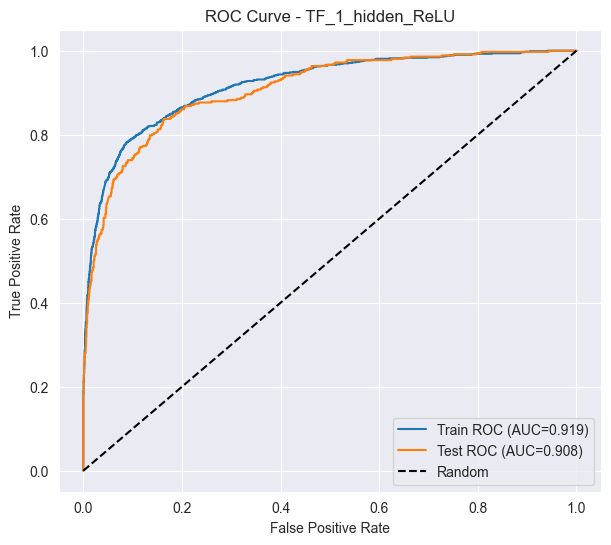

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step

TF_1_hidden_Tanh:
  Train Accuracy: 0.8984, Test Accuracy: 0.8865
  Train AUC:      0.9189, Test AUC:      0.9090


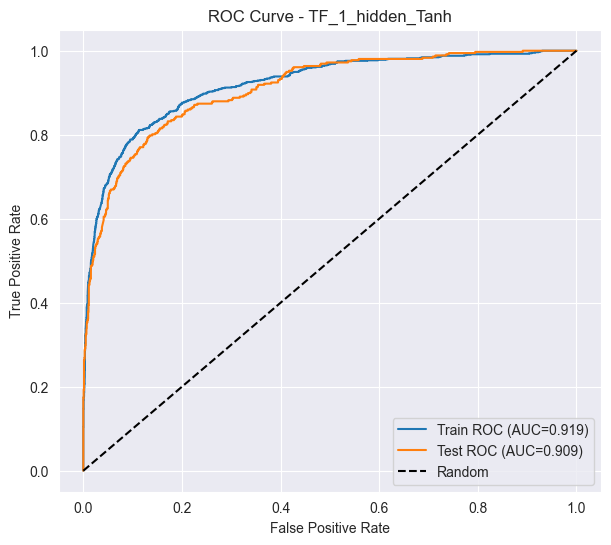

131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step

TF_2_hidden_ReLU_Dropout:
  Train Accuracy: 0.9032, Test Accuracy: 0.8937
  Train AUC:      0.9251, Test AUC:      0.9172


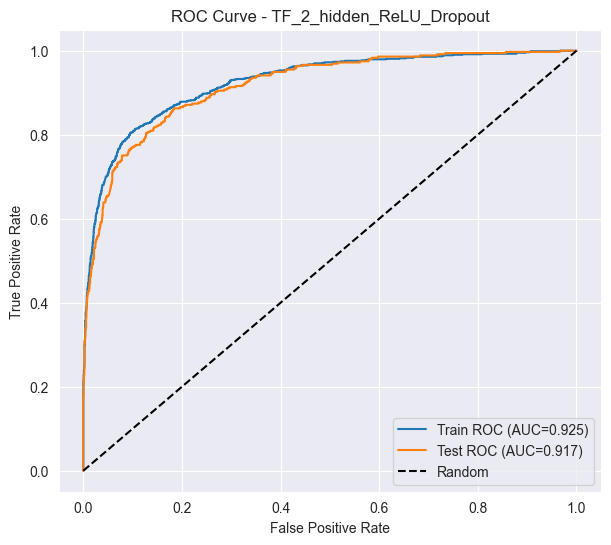

In [17]:
tf_results = {}

def eval_tf_model(name, model, X_train, y_train, X_test, y_test):
    # Probabilities
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()

    # Class predictions (threshold 0.5)
    y_train_pred = (y_train_prob >= 0.5).astype(int)
    y_test_pred = (y_test_prob >= 0.5).astype(int)

    # Accuracy
    acc_train = metrics.accuracy_score(y_train, y_train_pred)
    acc_test = metrics.accuracy_score(y_test, y_test_pred)

    # ROC & AUC
    fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_test_prob)

    auc_train = metrics.roc_auc_score(y_train, y_train_prob)
    auc_test = metrics.roc_auc_score(y_test, y_test_prob)

    # Store in dictionary
    tf_results[name] = {
        "acc_train": acc_train,
        "acc_test": acc_test,
        "auc_train": auc_train,
        "auc_test": auc_test,
        "fpr_train": fpr_train,
        "tpr_train": tpr_train,
        "fpr_test": fpr_test,
        "tpr_test": tpr_test,
        "y_test_prob": y_test_prob
    }

    print(f"\n{name}:")
    print(f"  Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}")
    print(f"  Train AUC:      {auc_train:.4f}, Test AUC:      {auc_test:.4f}")

    # Plot ROC for this model (train vs test)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.3f})")
    plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC={auc_test:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Evaluate all three TF models
eval_tf_model("TF_1_hidden_ReLU", tf_model_1, X_train_sel, y_train, X_test_sel, y_test)
eval_tf_model("TF_1_hidden_Tanh", tf_model_2, X_train_sel, y_train, X_test_sel, y_test)
eval_tf_model("TF_2_hidden_ReLU_Dropout", tf_model_3, X_train_sel, y_train, X_test_sel, y_test)

In [18]:
# Logistic Regression
logit_clf = LogisticRegression(max_iter=1000, solver="liblinear")
logit_clf.fit(X_train_sel, y_train)

y_test_prob_logit = logit_clf.predict_proba(X_test_sel)[:, 1]
fpr_logit, tpr_logit, _ = metrics.roc_curve(y_test, y_test_prob_logit)
auc_logit = metrics.roc_auc_score(y_test, y_test_prob_logit)

print("\nLogistic Regression:")
print(f"  Test AUC: {auc_logit:.4f}")

# Gradient Boosting
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_sel, y_train)

y_test_prob_gb = gb_clf.predict_proba(X_test_sel)[:, 1]
fpr_gb, tpr_gb, _ = metrics.roc_curve(y_test, y_test_prob_gb)
auc_gb = metrics.roc_auc_score(y_test, y_test_prob_gb)

print("\nGradient Boosting (Tree-based):")
print(f"  Test AUC: {auc_gb:.4f}")


Logistic Regression:
  Test AUC: 0.8985

Gradient Boosting (Tree-based):
  Test AUC: 0.9142


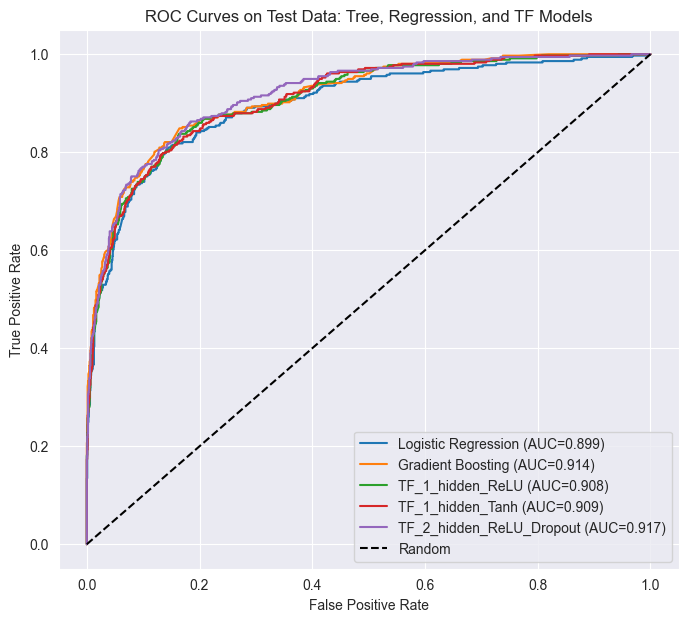

In [19]:

plt.figure(figsize=(8, 7))

# Regression (Logit)
plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC={auc_logit:.3f})")

# Tree-based (GBM)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.3f})")

# TF models (test ROC)
for name, res in tf_results.items():
    plt.plot(
        res["fpr_test"],
        res["tpr_test"],
        label=f"{name} (AUC={res['auc_test']:.3f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Data: Tree, Regression, and TF Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Tensor Flow Model to Predict Loss Given Default

In [20]:
# Only include defaulted loans (LGD is conditional)
df_lgd = df[df["TARGET_BAD_FLAG"] == 1].copy()

# Numeric predictors, excluding targets
numeric_cols = df_lgd.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_lgd = [c for c in numeric_cols if c not in ["TARGET_BAD_FLAG", "TARGET_LOSS_AMT"]]

# Drop missing values
df_lgd = df_lgd[feature_cols_lgd + ["TARGET_LOSS_AMT"]].dropna()

# Build X and Y
X_lgd = df_lgd[feature_cols_lgd].values.astype("f")
Y_lgd = df_lgd["TARGET_LOSS_AMT"].values.astype("f")

# Train/Test split
X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(
    X_lgd, Y_lgd,
    test_size=0.30,
    random_state=42
)

# Scale features
scaler_lgd = StandardScaler()
X_train_lgd_s = scaler_lgd.fit_transform(X_train_lgd)
X_test_lgd_s = scaler_lgd.transform(X_test_lgd)

print("LGD Train shape:", X_train_lgd_s.shape)
print("LGD Test shape:", X_test_lgd_s.shape)

LGD Train shape: (832, 29)
LGD Test shape: (357, 29)


In [21]:
base_lr = LinearRegression()

sfs_lgd = SFS(
    base_lr,
    k_features=10,                 # You can increase/decrease as needed
    forward=True,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

sfs_lgd = sfs_lgd.fit(X_train_lgd_s, y_train_lgd)

selected_idx_lgd = list(sfs_lgd.k_feature_idx_)
selected_features_lgd = [feature_cols_lgd[i] for i in selected_idx_lgd]

print("\nSelected LGD Features (SFS):")
for f in selected_features_lgd:
    print("  ", f)

# Subset feature matrices
X_train_lgd_sel = X_train_lgd_s[:, selected_idx_lgd]
X_test_lgd_sel = X_test_lgd_s[:, selected_idx_lgd]


Selected LGD Features (SFS):
   LOAN
   z_IMP_JOB_Self
   z_IMP_REASON_DebtCon
   IMP_VALUE
   IMP_YOJ
   IMP_DELINQ
   IMP_CLAGE
   IMP_CLNO
   M_DEBTINC
   IMP_DEBTINC


In [22]:
tf.random.set_seed(123)
input_dim_lgd = X_train_lgd_sel.shape[1]

def build_lgd_relu():
    model = Sequential()
    model.add(Dense(32, activation="relu", input_shape=(input_dim_lgd,)))
    model.add(Dense(1))  # regression output
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

def build_lgd_tanh():
    model = Sequential()
    model.add(Dense(32, activation="tanh", input_shape=(input_dim_lgd,)))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

def build_lgd_relu_dropout():
    model = Sequential()
    model.add(Dense(64, activation="relu", input_shape=(input_dim_lgd,)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model

In [23]:
EPOCHS = 60
BATCH_SIZE = 64

model_lgd_relu = build_lgd_relu()
hist_lgd_relu = model_lgd_relu.fit(
    X_train_lgd_sel, y_train_lgd,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

model_lgd_tanh = build_lgd_tanh()
hist_lgd_tanh = model_lgd_tanh.fit(
    X_train_lgd_sel, y_train_lgd,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

model_lgd_relu_do = build_lgd_relu_dropout()
hist_lgd_relu_do = model_lgd_relu_do.fit(
    X_train_lgd_sel, y_train_lgd,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("LGD TensorFlow models trained.")

LGD TensorFlow models trained.


In [24]:
lgd_results = {}

def eval_lgd_model(name, model):
    # Predictions
    train_pred = model.predict(X_train_lgd_sel).ravel()
    test_pred = model.predict(X_test_lgd_sel).ravel()

    # RMSE
    rmse_train = math.sqrt(metrics.mean_squared_error(y_train_lgd, train_pred))
    rmse_test = math.sqrt(metrics.mean_squared_error(y_test_lgd, test_pred))

    lgd_results[name] = {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    }

    print(f"\n{name}:")
    print(f"  Train RMSE: {rmse_train:.3f}")
    print(f"  Test RMSE:  {rmse_test:.3f}")

eval_lgd_model("TF_LGD_ReLU", model_lgd_relu)
eval_lgd_model("TF_LGD_Tanh", model_lgd_tanh)
eval_lgd_model("TF_LGD_ReLU_Dropout", model_lgd_relu_do)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

TF_LGD_ReLU:
  Train RMSE: 17271.448
  Test RMSE:  17009.251
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

TF_LGD_Tanh:
  Train RMSE: 17303.620
  Test RMSE:  17039.031
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

TF_LGD_ReLU_Dropout:
  Train RMSE: 13090.884
  Test RMSE:  13062.216


In [25]:
# Linear Regression
lr_lgd = LinearRegression()
lr_lgd.fit(X_train_lgd_sel, y_train_lgd)
lr_lgd_pred = lr_lgd.predict(X_test_lgd_sel)
rmse_lr = math.sqrt(metrics.mean_squared_error(y_test_lgd, lr_lgd_pred))

print("\nLinear Regression (baseline):")
print(f"  Test RMSE: {rmse_lr:.3f}")

# Gradient Boosting Regression (tree-based)
gbr_lgd = GradientBoostingRegressor(random_state=42)
gbr_lgd.fit(X_train_lgd_sel, y_train_lgd)
gbr_lgd_pred = gbr_lgd.predict(X_test_lgd_sel)
rmse_gbr = math.sqrt(metrics.mean_squared_error(y_test_lgd, gbr_lgd_pred))

print("\nGradient Boosting Regressor:")
print(f"  Test RMSE: {rmse_gbr:.3f}")


Linear Regression (baseline):
  Test RMSE: 3835.010

Gradient Boosting Regressor:
  Test RMSE: 2961.021


In [26]:
print("\n===== LGD Model Comparison: Test RMSE =====")
print(f"Linear Regression:           {rmse_lr:.3f}")
print(f"Gradient Boosting Regressor: {rmse_gbr:.3f}")
print(f"TF_LGD_ReLU:                 {lgd_results['TF_LGD_ReLU']['rmse_test']: .3f}")
print(f"TF_LGD_Tanh:                 {lgd_results['TF_LGD_Tanh']['rmse_test']:.3f}")
print(f"TF_LGD_ReLU_Dropout:         {lgd_results['TF_LGD_ReLU_Dropout']['rmse_test']:.3f}")


===== LGD Model Comparison: Test RMSE =====
Linear Regression:           3835.010
Gradient Boosting Regressor: 2961.021
TF_LGD_ReLU:                 17009.251
TF_LGD_Tanh:                 17039.031
TF_LGD_ReLU_Dropout:         13062.216
